# Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
np.random.seed(42)

path = '/kaggle/input/datasets/frhanr/dataset/raw_bandungjaket.csv'
df = pd.read_csv(path, dtype=str, low_memory=False)

print('Jumlah baris :', len(df))
print('Jumlah kolom :', df.shape[1])
df.head()

Jumlah baris : 742182
Jumlah kolom : 50


,Source.Name,No. Pesanan,Status Pesanan,Shipped by Advance Fulfilment,Status Pembatalan/ Pengembalian,No. Resi,Opsi Pengiriman,Antar ke counter/ pick-up,Pesanan Harus Dikirimkan Sebelum (Menghindari keterlambatan),Waktu Pengiriman Diatur,...,Perkiraan Ongkos Kirim,Catatan dari Pembeli,Catatan,Username (Pembeli),Nama Penerima,No. Telepon,Alamat Pengiriman,Kota/Kabupaten,Provinsi,Waktu Pesanan Selesai
0,Order.completed.20201001_20201031_part_1_of_2....,2010016KQJSXPW,Selesai,N,NaN,JP2497892527,J&T Express,Pickup,2020-10-05 16:34,2020-10-01 19:41,...,37.000,NaN,NaN,agim222,A******h,******20,Po******,KAB. TANGGAMUS,LAMPUNG,2020-10-02 13:33
1,Order.completed.20201001_20201031_part_1_of_2....,2010016N8PJDT2,Selesai,N,NaN,JP6792722118,J&T Express,Pickup,2020-10-05 12:23,2020-10-01 19:41,...,14.000,NaN,NaN,rizkibudhi_13,R******i,******31,Jl******,KOTA JAKARTA SELATAN,DKI JAKARTA,2020-10-02 14:54
2,Order.completed.20201001_20201031_part_1_of_2....,2010015MG4GFPC,Selesai,N,NaN,JP6655601792,J&T Express,Pickup,2020-10-05 02:37,2020-10-01 19:41,...,12.000,NaN,NaN,sitinrrhmhh,S******h,******99,Jl******,KOTA BANDUNG,JAWA BARAT,2020-10-02 15:59
3,Order.completed.20201001_20201031_part_1_of_2....,2010015D72WHNR,Selesai,N,NaN,JP9642268592,J&T Express,Pickup,2020-10-05 00:30,2020-10-01 19:41,...,12.000,NaN,NaN,_bnw_,H******P,******55,Ke******,KAB. BANDUNG,JAWA BARAT,2020-10-02 16:13
4,Order.completed.20201001_20201031_part_1_of_2....,2010016HGXUBHH,Selesai,N,NaN,JP8490402495,J&T Express,Pickup,2020-10-05 11:18,2020-10-01 19:41,...,18.000,NaN,NaN,NaN,S******i,******35,Du******,KAB. PANGANDARAN,JAWA BARAT,2020-10-02 16:21


In [2]:
kolom = {
    'No. Pesanan': 'order_id',
    'Username (Pembeli)': 'username',
    'Waktu Pesanan Selesai': 'completion_date',
    'Total Pembayaran': 'total_amount',
    'Status Pesanan': 'order_status',
    'Status Pembatalan/ Pengembalian': 'cancel_status',
}
df = df.rename(columns=kolom)[list(kolom.values())]
df.head()

,order_id,username,completion_date,total_amount,order_status,cancel_status
0,2010016KQJSXPW,agim222,2020-10-02 13:33,89.500,Selesai,NaN
1,2010016N8PJDT2,rizkibudhi_13,2020-10-02 14:54,54.000,Selesai,NaN
2,2010015MG4GFPC,sitinrrhmhh,2020-10-02 15:59,40.840,Selesai,NaN
3,2010015D72WHNR,_bnw_,2020-10-02 16:13,50.338,Selesai,NaN
4,2010016HGXUBHH,NaN,2020-10-02 16:21,42.659,Selesai,NaN


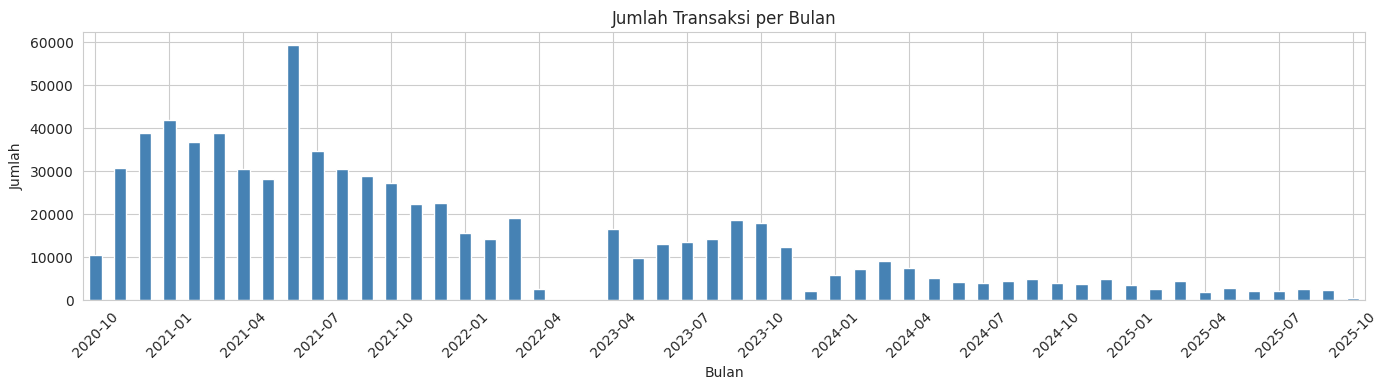

Periode data: 2020-10-02 13:33:00 sampai 2025-10-15 23:21:00


In [3]:
tgl = pd.to_datetime(df['completion_date'], errors='coerce')
per_bulan = df[tgl.notna()].groupby(tgl.dt.to_period('M')).size()

plt.figure(figsize=(14, 4))
per_bulan.plot(kind='bar', color='steelblue')
plt.title('Jumlah Transaksi per Bulan')
plt.xlabel('Bulan'); plt.ylabel('Jumlah')
plt.xticks(range(0, len(per_bulan), 3), rotation=45)
plt.tight_layout(); plt.show()

print('Periode data:', tgl.min(), 'sampai', tgl.max())

In [4]:
print('Status Pesanan:')
print(df['order_status'].value_counts(), '\n')
print('Status Pembatalan:')
print(df['cancel_status'].value_counts(dropna=False))

Status Pesanan:
order_status
Selesai             734452
Pesanan Diterima      7730
Name: count, dtype: int64 

Status Pembatalan:
cancel_status
NaN                      730575
Permintaan Disetujui       8200
Permintaan Dibatalkan      3329
Masalah Diselesaikan         78
Name: count, dtype: int64


-----
# Preprocessing Data

In [5]:
# bersihkan format rupiah -> angka
def ke_angka(x):
    if pd.isna(x):
        return np.nan
    s = str(x).replace('Rp', '').replace(' ', '').replace('.', '').replace(',', '.')
    try:
        return float(s)
    except:
        return np.nan

df['total_amount'] = df['total_amount'].apply(ke_angka)
df['completion_date'] = pd.to_datetime(df['completion_date'], errors='coerce')

In [6]:
sebelum = len(df)
df = df.drop_duplicates(subset='order_id', keep='first')
print('Baris item digabung ke pesanan :', sebelum - len(df))
print('Jumlah pesanan unik            :', len(df))

Baris item digabung ke pesanan : 187206
Jumlah pesanan unik            : 554976


In [7]:
# hapus baris yang datanya tidak lengkap
df = df.dropna(subset=['username', 'completion_date', 'total_amount'])
print('Setelah hapus nilai kosong:', len(df))

Setelah hapus nilai kosong: 484997


In [8]:
# hanya transaksi yang benar-benar selesai/diterima
df = df[df['order_status'].str.strip().isin(['Selesai', 'Pesanan Diterima'])]
# buang transaksi yang sudah di-refund (pembatalan disetujui)
df = df[df['cancel_status'].fillna('').str.strip() != 'Permintaan Disetujui']

# buang nilai 0
df = df[df['total_amount'] > 0]

print('Jumlah transaksi valid:', len(df))
print('Periode:', df['completion_date'].min().date(), 's/d', df['completion_date'].max().date())

Jumlah transaksi valid: 481682
Periode: 2020-10-02 s/d 2025-10-15


------
# Pembentukan RFM

In [9]:
# tanggal acuan = transaksi terbaru + 1 hari
acuan = df['completion_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('username').agg(
    last_buy=('completion_date', 'max'),
    frequency=('order_id', 'nunique'),
    monetary=('total_amount', 'sum'),
).reset_index()
rfm['recency'] = (acuan - rfm['last_buy']).dt.days
rfm = rfm[['username', 'recency', 'frequency', 'monetary']]

print('Tanggal acuan :', acuan.date())
print('Jumlah pelanggan:', len(rfm))
rfm.describe()

Tanggal acuan : 2025-10-16
Jumlah pelanggan: 390167


,recency,frequency,monetary
count,390167.000000,390167.000000,3.901670e+05
mean,1179.480594,1.234553,8.752947e+04
std,501.141459,4.473820,4.375651e+05
min,1.000000,1.000000,1.800000e+01
25%,748.000000,1.000000,4.500000e+04
50%,1399.000000,1.000000,5.705600e+04
75%,1596.000000,1.000000,8.573100e+04
max,1840.000000,1892.000000,1.769700e+08


In [10]:
# cek seberapa miring distribusinya
from scipy.stats import skew
for k in ['recency', 'frequency', 'monetary']:
    print(f'Skewness {k}: {skew(rfm[k]):.2f}')

print('\nPelanggan beli sekali (frequency=1): %.1f%%' % ((rfm['frequency'] == 1).mean() * 100))

Skewness recency: -0.52
Skewness frequency: 308.72
Skewness monetary: 228.44

Pelanggan beli sekali (frequency=1): 89.2%


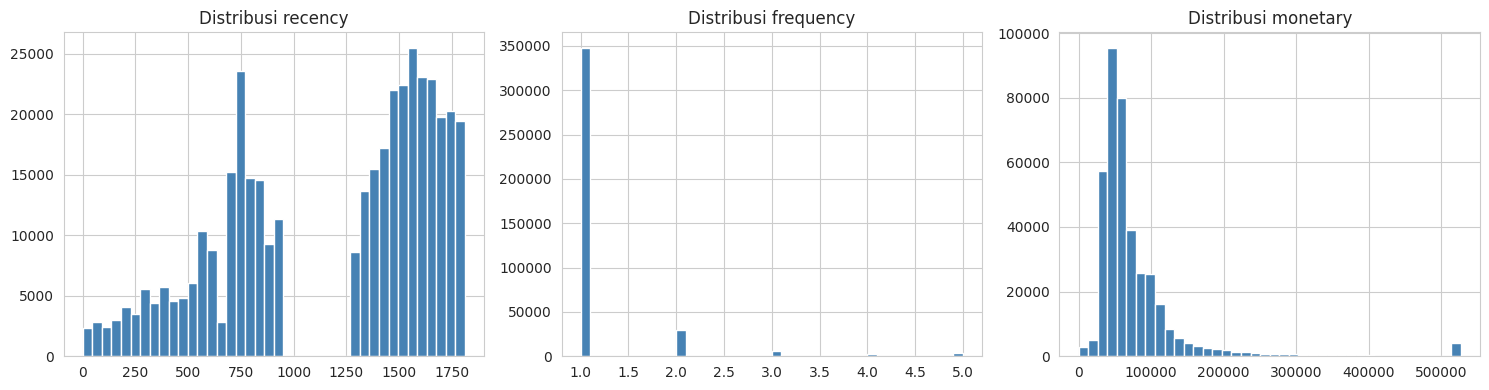

In [11]:
# distribusi tiap fitur
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, k in enumerate(['recency', 'frequency', 'monetary']):
    ax[i].hist(rfm[k].clip(upper=rfm[k].quantile(0.99)), bins=40, color='steelblue')
    ax[i].set_title('Distribusi ' + k)
plt.tight_layout(); plt.show()

----
# Split Dataset
Train 80%
Test 20%

In [12]:
from sklearn.model_selection import train_test_split

# kelompok frekuensi untuk stratifikasi
def bin_freq(f):
    if f == 1: return 'a'
    elif f <= 3: return 'b'
    elif f <= 5: return 'c'
    else: return 'd'
strata = rfm['frequency'].apply(bin_freq)

train, test = train_test_split(rfm, test_size=0.2, random_state=42, stratify=strata)
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

print('Data latih:', len(train))
print('Data uji  :', len(test))

Data latih: 312133
Data uji  : 78034


----
# Normalisasi Data

In [13]:
from sklearn.preprocessing import PowerTransformer

fitur = ['recency', 'frequency', 'monetary']
scaler = PowerTransformer(method='yeo-johnson',standardize=True).fit(train[fitur].values)
X_train = scaler.transform(train[fitur].values)
X_test  = scaler.transform(test[fitur].values)

print('Ringkasan data latih setelah PowerTransformer :')
print(pd.DataFrame(X_train, columns=fitur).describe().round(2))

Ringkasan data latih setelah PowerTransformer :
         recency  frequency   monetary
count  312133.00  312133.00  312133.00
mean       -0.00      -0.00       0.00
std         1.00       1.00       1.00
min        -2.08      -0.35     -25.03
25%        -0.91      -0.35      -0.54
50%         0.41      -0.35      -0.14
75%         0.84      -0.35       0.52
max         1.39       2.87       7.48


---
# Reduksi UMAP

2026-06-28 21:40:32.280668: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782682832.538962      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782682832.612918      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782682833.196659      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782682833.196707      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782682833.196710      23 computation_placer.cc:177] computation placer alr

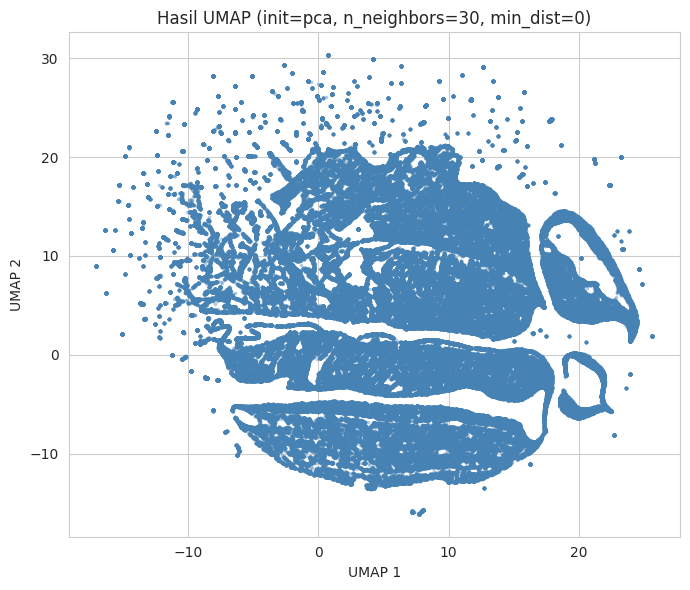

In [14]:
import umap

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.0,
    n_components=2,
    init='pca',
    random_state=42,
)
emb_train = reducer.fit_transform(X_train)
emb_test  = reducer.transform(X_test)

import matplotlib.pyplot as plt
plt.figure(figsize=(7, 6))
plt.scatter(emb_train[:, 0], emb_train[:, 1], s=3, alpha=0.3, color='steelblue')
plt.title('Hasil UMAP (init=pca, n_neighbors=30, min_dist=0)')
plt.xlabel('UMAP 1'); plt.ylabel('UMAP 2')
plt.tight_layout(); plt.show()

----
# Klasterisasi HDBSCAN

In [15]:
import hdbscan

for eps in [0.0, 0.5, 1.0, 2.0, 3.0]:
    c = hdbscan.HDBSCAN(min_cluster_size=500, min_samples=5,
                        cluster_selection_epsilon=float(eps),
                        gen_min_span_tree=True, core_dist_n_jobs=1)
    lab = c.fit_predict(emb_train)
    jml = len(set(lab)) - (1 if -1 in lab else 0)
    noise = (lab == -1).mean() * 100
    print(f'eps={eps:.1f} -> klaster={jml:3d}, noise={noise:5.1f}%, DBCV={c.relative_validity_:.3f}')

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


eps=0.0 -> klaster= 25, noise=  4.3%, DBCV=0.205
eps=0.5 -> klaster= 17, noise=  3.8%, DBCV=0.201
eps=1.0 -> klaster=  8, noise=  2.5%, DBCV=0.005
eps=2.0 -> klaster=  2, noise=  0.5%, DBCV=0.025
eps=3.0 -> klaster=  2, noise=  0.5%, DBCV=0.025


In [16]:
# konfigurasi final terpilih dari hasil tuning
MCS, MS, EPS = 500, 5, 1.0

model = hdbscan.HDBSCAN(min_cluster_size=MCS, min_samples=MS,
                        cluster_selection_epsilon=EPS,
                        gen_min_span_tree=True, prediction_data=True,
                        core_dist_n_jobs=1)
label_train = model.fit_predict(emb_train)
label_test, _ = hdbscan.approximate_predict(model, emb_test)

train['cluster'] = label_train
test['cluster']  = label_test

jml = len(set(label_train)) - (1 if -1 in label_train else 0)
print('Jumlah klaster :', jml)
print('Noise          : %.1f%%' % ((label_train == -1).mean() * 100))
print(train['cluster'].value_counts().sort_index())

Jumlah klaster : 8
Noise          : 2.5%
cluster
-1      7741
 0       512
 1      1435
 2      1381
 3      1244
 4       537
 5       630
 6       665
 7    297988
Name: count, dtype: int64


----
# Evaluasi Model

In [17]:
from sklearn.metrics import silhouette_score

def silhouette(emb, label):
    m = label != -1
    if len(set(label[m])) < 2:
        return None
    e, l = emb[m], label[m]
    if len(l) > 20000:
        idx = np.random.default_rng(42).choice(len(l), 20000, replace=False)
        e, l = e[idx], l[idx]
    return silhouette_score(e, l)

sil_umap = silhouette(emb_train, label_train)
sil_rfm  = silhouette(X_train, label_train)
print('Silhouette (ruang UMAP) :', round(sil_umap, 4) if sil_umap is not None else 'N/A')
print('Silhouette (ruang RFM)  :', round(sil_rfm, 4) if sil_rfm is not None else 'N/A')
print('Noise data latih        : %.1f%%' % ((label_train == -1).mean() * 100))
print('Noise data uji          : %.1f%%' % ((label_test == -1).mean() * 100))
print('DBCV (info tambahan)    :', round(model.relative_validity_, 4))

Silhouette (ruang UMAP) : 0.096
Silhouette (ruang RFM)  : -0.2851
Noise data latih        : 2.5%
Noise data uji          : 2.4%
DBCV (info tambahan)    : 0.0049


In [18]:
from sklearn.metrics import adjusted_rand_score

rng = np.random.default_rng(42)
ari = []
for _ in range(10):
    idx = rng.choice(len(emb_train), int(0.8 * len(emb_train)), replace=False)
    lab = hdbscan.HDBSCAN(min_cluster_size=MCS, min_samples=MS,
                          cluster_selection_epsilon=EPS,
                          core_dist_n_jobs=1).fit_predict(emb_train[idx])
    ari.append(adjusted_rand_score(label_train[idx], lab))

print('Cluster Stability Index : %.4f (+/- %.4f)' % (np.mean(ari), np.std(ari)))

Cluster Stability Index : 0.8551 (+/- 0.0790)


----
# Segmentasi

In [19]:
profil = train[train['cluster'] != -1].groupby('cluster').agg(
    jumlah=('username', 'count'),
    recency=('recency', 'median'),
    frequency=('frequency', 'median'),
    monetary=('monetary', 'median'),
).reset_index()
profil['persen'] = (profil['jumlah'] / len(train) * 100).round(1)

print('Noise: %.1f%%' % ((train['cluster'] == -1).mean() * 100))
print(profil.to_string(index=False))

Noise: 2.5%
 cluster  jumlah  recency  frequency  monetary  persen
       0     512   1676.0        1.0    3999.0     0.2
       1    1435   1569.0        1.0   50000.0     0.5
       2    1381   1673.0        1.0   15149.0     0.4
       3    1244   1601.0        1.0   35000.0     0.4
       4     537   1574.0        1.0   50000.0     0.2
       5     630   1654.0        1.0   35150.0     0.2
       6     665   1595.0        1.0   46350.0     0.2
       7  297988   1381.0        1.0   58500.0    95.5


In [20]:
print('pelanggan one-timer (frequency==1):', round((rfm['frequency']==1).mean()*100, 1))
print('\nDistribusi RFM pelanggan:')
print(rfm[['recency','frequency','monetary']].describe([.1,.25,.5,.75,.9,.99]).round(1))

pelanggan one-timer (frequency==1): 89.2

Distribusi RFM pelanggan:
        recency  frequency     monetary
count  390167.0   390167.0     390167.0
mean     1179.5        1.2      87529.5
std       501.1        4.5     437565.1
min         1.0        1.0         18.0
10%       460.0        1.0      35692.0
25%       748.0        1.0      45000.0
50%      1399.0        1.0      57056.0
75%      1596.0        1.0      85731.0
90%      1725.0        2.0     124079.8
99%      1813.0        5.0     527285.8
max      1840.0     1892.0  176969993.0


In [21]:
# beri label segmen berdasarkan nilai tengah populasi
r_mid = train['recency'].median()
f_mid = train['frequency'].median()
m_mid = train['monetary'].median()

def beri_label(b):
    if b['recency'] <= r_mid and b['frequency'] >= f_mid and b['monetary'] >= m_mid:
        return 'Pelanggan Unggulan'
    if b['recency'] <= r_mid and b['monetary'] >= m_mid:
        return 'Pelanggan Loyal'
    if b['recency'] <= r_mid:
        return 'Pelanggan Baru/Aktif'
    if b['monetary'] >= m_mid:
        return 'Berisiko Berhenti'
    return 'Pelanggan Pasif'

profil['segmen'] = profil.apply(beri_label, axis=1)
profil[['cluster', 'segmen', 'jumlah', 'persen', 'recency', 'frequency', 'monetary']]

,cluster,segmen,jumlah,persen,recency,frequency,monetary
0,0,Pelanggan Pasif,512,0.2,1676.0,1.0,3999.0
1,1,Pelanggan Pasif,1435,0.5,1569.0,1.0,50000.0
2,2,Pelanggan Pasif,1381,0.4,1673.0,1.0,15149.0
3,3,Pelanggan Pasif,1244,0.4,1601.0,1.0,35000.0
4,4,Pelanggan Pasif,537,0.2,1574.0,1.0,50000.0
5,5,Pelanggan Pasif,630,0.2,1654.0,1.0,35150.0
6,6,Pelanggan Pasif,665,0.2,1595.0,1.0,46350.0
7,7,Pelanggan Unggulan,297988,95.5,1381.0,1.0,58500.0


In [22]:
# Pipeline lapis 2 (pelanggan beli lebih dari 1x)
import numpy as np, pandas as pd, umap, hdbscan
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import silhouette_score

assert 'rfm' in globals(), "Jalankan cell pembentukan RFM."
fitur = ['recency', 'frequency', 'monetary']

# Subset repeat buyer
repeat = rfm[rfm['frequency'] >= 2].reset_index(drop=True)
print(f'Repeat buyer (freq>=2): {len(repeat):,} '
      f'({len(repeat)/len(rfm)*100:.1f}% populasi)\n')
print(repeat[fitur].describe([.5, .9, .99]).round(1), '\n')

# Pipeline PowerTransformer -> UMAP
X = PowerTransformer(standardize=True).fit_transform(repeat[fitur].values)
emb = umap.UMAP(n_neighbors=30, min_dist=0.0, n_components=2,
                init='pca', random_state=42).fit_transform(X)

# Sweep parameter (format sama tuning populasi penuh)
def sil(e, lab):
    m = lab != -1
    if len(set(lab[m])) < 2: return None
    if m.sum() > 20000:
        idx = np.random.default_rng(42).choice(np.where(m)[0], 20000, replace=False)
        return silhouette_score(e[idx], lab[idx])
    return silhouette_score(e[m], lab[m])

print(f"{'mcs':>4}{'eps':>6}{'klaster':>9}{'noise%':>8}{'DBCV':>8}{'sil_UMAP':>10}{'sil_RFM':>9}")
hasil = []
for mcs in [50, 100, 200]:
    for eps in [0.0, 0.5, 1.0]:
        c = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=5,
                            cluster_selection_epsilon=float(eps),
                            gen_min_span_tree=True, core_dist_n_jobs=1).fit(emb)
        lab = c.labels_
        jml = len(set(lab)) - (1 if -1 in lab else 0)
        noise = (lab == -1).mean()*100
        su, sr = sil(emb, lab), sil(X, lab)
        hasil.append((mcs, eps, jml, noise, c.relative_validity_, su, sr, lab))
        f = lambda v: f'{v:.3f}' if v is not None else 'N/A'
        print(f"{mcs:>4}{eps:>6.1f}{jml:>9}{noise:>8.1f}"
              f"{c.relative_validity_:>8.3f}{f(su):>10}{f(sr):>9}")

# 4) Auto-pilih config (2<=klaster<=15, noise<40%) DBCV tertinggi
kandidat = [h for h in hasil if 2 <= h[2] <= 15 and h[3] < 40] or hasil
best = max(kandidat, key=lambda h: h[4])
repeat['cluster'] = best[7]
print(f"\nConfig terpilih: mcs={best[0]}, eps={best[1]}, "
      f"klaster={best[2]}, noise={best[3]:.1f}%, DBCV={best[4]:.3f}")

# Profil klaster
profil = (repeat[repeat['cluster'] != -1]
          .groupby('cluster')[fitur].median()
          .join(repeat[repeat['cluster'] != -1].groupby('cluster').size().rename('jumlah')))
print('\nProfil klaster repeat buyer (median):')
print(profil.round(1).to_string())

Repeat buyer (freq>=2): 42,248 (10.8% populasi)

       recency  frequency     monetary
count  42248.0    42248.0      42248.0
mean    1304.6        3.2     282637.3
std      446.2       13.4    1304207.5
min        4.0        2.0       4800.0
50%     1481.0        2.0     145005.5
90%     1714.0        5.0     456998.9
99%     1800.0       16.0    2367138.5
max     1837.0     1892.0  176969993.0 



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


 mcs   eps  klaster  noise%    DBCV  sil_UMAP  sil_RFM
  50   0.0       96     5.2   0.548     0.161    0.211
  50   0.5        7     0.0   0.757     0.286    0.394
  50   1.0        6     0.0   0.789     0.325    0.430
 100   0.0        8     0.0   0.750     0.270    0.375
 100   0.5        7     0.0   0.757     0.286    0.394
 100   1.0        6     0.0   0.789     0.325    0.430
 200   0.0        8     0.0   0.750     0.270    0.375
 200   0.5        7     0.0   0.757     0.286    0.394
 200   1.0        6     0.0   0.789     0.325    0.430

Config terpilih: mcs=50, eps=1.0, klaster=6, noise=0.0%, DBCV=0.789

Profil klaster repeat buyer (median):
         recency  frequency  monetary  jumlah
cluster                                      
0          703.0        2.0  118391.0    8319
1         1567.0        2.0  116051.0   20780
2          620.0        5.0  475691.0    1259
3          688.0        3.0  185045.0    1400
4         1563.0        3.0  199245.0    5007
5         1539.0    

In [23]:
from sklearn.metrics import adjusted_rand_score

assert 'emb' in globals() and 'repeat' in globals() and 'best' in globals(), \
    "Jalankan dulu cell 30"

# config terpilih lapis 2 dari hasil sweep di cell 30 (mcs, eps); min_samples=5 sama seperti sweep
MCS2, EPS2, MS2 = best[0], float(best[1]), 5
label_full = repeat['cluster'].values   # label lapis 2 final (klaster dari emb penuh)

rng = np.random.default_rng(42)
ari2 = []
for _ in range(10):
    idx = rng.choice(len(emb), int(0.8 * len(emb)), replace=False)
    lab = hdbscan.HDBSCAN(min_cluster_size=MCS2, min_samples=MS2,
                          cluster_selection_epsilon=EPS2,
                          core_dist_n_jobs=1).fit_predict(emb[idx])
    ari2.append(adjusted_rand_score(label_full[idx], lab))

print('Cluster Stability Index (Lapis 2) : %.4f (+/- %.4f)' % (np.mean(ari2), np.std(ari2)))

Cluster Stability Index (Lapis 2) : 0.9092 (+/- 0.1276)


In [24]:
# Beri label segmen untuk klaster lapis 2 (pelanggan repeat)
profil = profil.reset_index()  # 'cluster' jadi kolom biasa

r_mid = repeat['recency'].median()
f_p75 = repeat['frequency'].quantile(0.75)
m_p75 = repeat['monetary'].quantile(0.75)

print(f"Acuan -> recency median: {r_mid}, frequency P75: {f_p75}, monetary P75: {m_p75}\n")

def beri_label_repeat(b):
    baru = b['recency'] <= r_mid
    sering = b['frequency'] >= f_p75
    bernilai = b['monetary'] >= m_p75

    if baru and sering and bernilai:
        return 'Pelanggan Unggulan'
    if not baru and sering and bernilai:
        return 'Pelanggan Bernilai Terancam'
    if baru and (sering or bernilai):
        return 'Pelanggan Aktif'
    if not baru and (sering or bernilai):
        return 'Pelanggan Berisiko Berhenti'
    if baru:
        return 'Pelanggan Potensial'
    return 'Pelanggan Dorman'

profil['segmen'] = profil.apply(beri_label_repeat, axis=1)
profil[['cluster', 'segmen', 'jumlah', 'recency', 'frequency', 'monetary']].sort_values('cluster')

Acuan -> recency median: 1481.0, frequency P75: 3.0, monetary P75: 233238.0



,cluster,segmen,jumlah,recency,frequency,monetary
0,0,Pelanggan Potensial,8319,703.0,2.0,118391.0
1,1,Pelanggan Dorman,20780,1567.0,2.0,116051.0
2,2,Pelanggan Unggulan,1259,620.0,5.0,475691.0
3,3,Pelanggan Aktif,1400,688.0,3.0,185045.0
4,4,Pelanggan Berisiko Berhenti,5007,1563.0,3.0,199245.0
5,5,Pelanggan Bernilai Terancam,5483,1539.0,5.0,458654.0


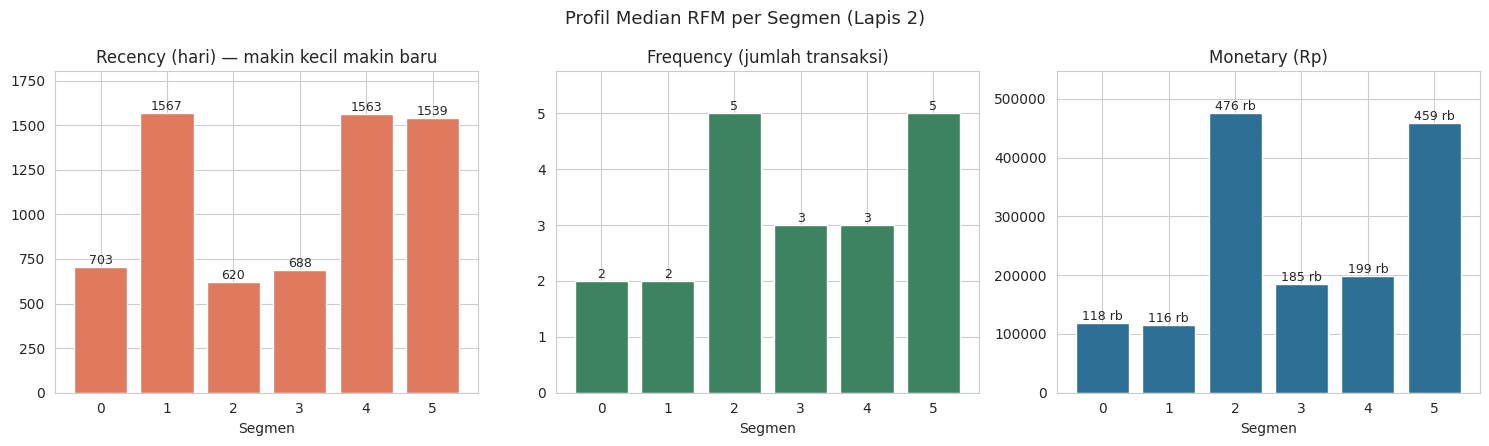

In [25]:
# Profil RFM per segmen
import matplotlib.pyplot as plt

seg = repeat[repeat['cluster'] != -1].copy()
prof = seg.groupby('cluster')[['recency', 'frequency', 'monetary']].median()
ids = prof.index.astype(str)

judul = {'recency': 'Recency (hari) — makin kecil makin baru',
         'frequency': 'Frequency (jumlah transaksi)',
         'monetary': 'Monetary (Rp)'}
warna = {'recency': '#e07a5f', 'frequency': '#3d8361', 'monetary': '#2e6f95'}

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
for j, f in enumerate(['recency', 'frequency', 'monetary']):
    bars = ax[j].bar(ids, prof[f].values, color=warna[f])
    ax[j].set_title(judul[f]); ax[j].set_xlabel('Segmen')
    for b, v in zip(bars, prof[f].values):
        if f == 'monetary':
            lbl = f'{v/1e6:.2f} jt' if v >= 1e6 else f'{v/1e3:.0f} rb'
        else:
            lbl = f'{v:.0f}'
        ax[j].text(b.get_x() + b.get_width()/2, v, lbl, ha='center', va='bottom', fontsize=9)
    ax[j].margins(y=0.15)
fig.suptitle('Profil Median RFM per Segmen (Lapis 2)', fontsize=13)
plt.tight_layout(); plt.show()

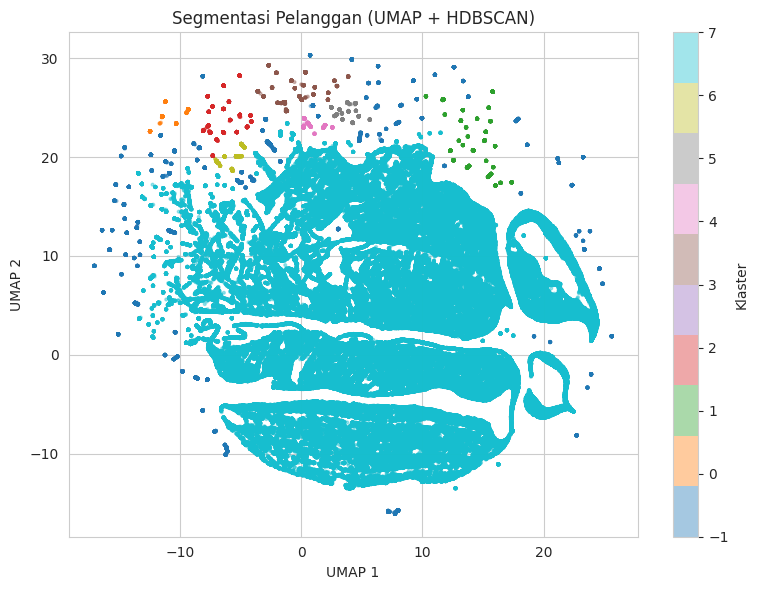

In [26]:
# visualisasi klaster pada hasil UMAP
plt.figure(figsize=(8, 6))
plt.scatter(emb_train[:, 0], emb_train[:, 1], s=4, alpha=0.4, c=label_train, cmap='tab10')
plt.title('Segmentasi Pelanggan (UMAP + HDBSCAN)')
plt.xlabel('UMAP 1'); plt.ylabel('UMAP 2')
plt.colorbar(label='Klaster')
plt.tight_layout(); plt.show()

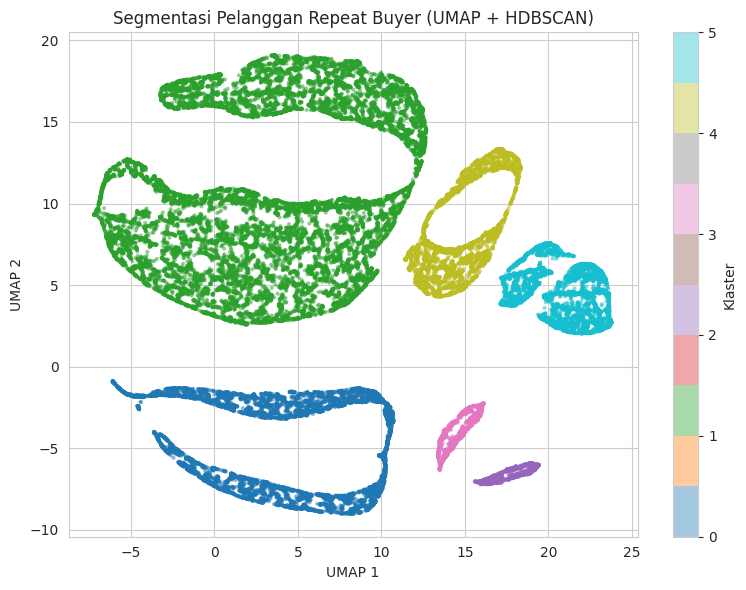

In [27]:
# visualisasi klaster pada hasil UMAP (lapis 2)
plt.figure(figsize=(8, 6))
mask = repeat['cluster'] != -1
plt.scatter(emb[mask, 0], emb[mask, 1], s=4, alpha=0.4, c=repeat['cluster'][mask], cmap='tab10')
plt.title('Segmentasi Pelanggan Repeat Buyer (UMAP + HDBSCAN)')
plt.xlabel('UMAP 1'); plt.ylabel('UMAP 2')
plt.colorbar(label='Klaster')
plt.tight_layout(); plt.show()

In [28]:
import joblib
joblib.dump(scaler, 'scaler.pkl')           # PowerTransformer Yeo-Johnson
joblib.dump(reducer, 'umap_reducer.pkl')    # UMAP fitted (bukan fit baru)
joblib.dump(model, 'hdbscan_model.pkl')     # HDBSCAN + prediction_data=True

import os
for f in os.listdir('/kaggle/working/'):
    size = os.path.getsize(f'/kaggle/working/{f}')
    print(f'{f} → {size/1024:.1f} KB')

umap_reducer.pkl → 262570.6 KB
scaler.pkl → 0.9 KB
__notebook__.ipynb → 722.3 KB
hdbscan_model.pkl → 51472.2 KB
